# Seoul Bike Dataset: Selecting Polynomial Features for Rental Demand
This notebook tunes polynomial feature expansion for a linear regression model that predicts rented bike counts.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

## Data Inspection
The bike rental data is loaded, filtered to functioning days, enriched with date features, and split into training and test sets.


In [ ]:
bike = pd.read_csv("../data/seoul_bike.csv", encoding="unicode_escape")
bike = bike[bike["Functioning Day"] == "Yes"]

bike["Date"] = pd.to_datetime(bike["Date"], format="%d/%m/%Y")

bike["Month"] = bike["Date"].dt.month
bike["Day"] = bike["Date"].dt.day

X = bike.drop(["Date", "Rented Bike Count", "Functioning Day"], axis=1)
y = bike["Rented Bike Count"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#X_train.hist(figsize=(14, 10), bins=30)
X_train.info()




<class 'pandas.core.frame.DataFrame'>
Index: 6772 entries, 8691 to 7469
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Hour                       6772 non-null   int64  
 1   Temperature(°C)            6772 non-null   float64
 2   Humidity(%)                6772 non-null   int64  
 3   Wind speed (m/s)           6772 non-null   float64
 4   Visibility (10m)           6772 non-null   int64  
 5   Dew point temperature(°C)  6772 non-null   float64
 6   Solar Radiation (MJ/m2)    6772 non-null   float64
 7   Rainfall(mm)               6772 non-null   float64
 8   Snowfall (cm)              6772 non-null   float64
 9   Seasons                    6772 non-null   object 
 10  Holiday                    6772 non-null   object 
 11  Month                      6772 non-null   int32  
 12  Day                        6772 non-null   int32  
dtypes: float64(6), int32(2), int64(3), object(2)
memor

## Preprocessing
Numerical features are expanded with polynomial terms and standardized, while categorical features are one-hot encoded.


In [ ]:
num_pipeline = make_pipeline(
    PolynomialFeatures(include_bias=False),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, X_train.select_dtypes(include=["float64", "int64"]).columns),
    ("cat", cat_pipeline, X_train.select_dtypes(include=["object"]).columns)
])


## Model Selection
Grid search selects the polynomial degree for the regression pipeline.


Test R2: 0.6631404644642558
Test MSE: 132246.4597076441
Test RMSE: 363.6570633270363
Test MAE: 272.0475145034874


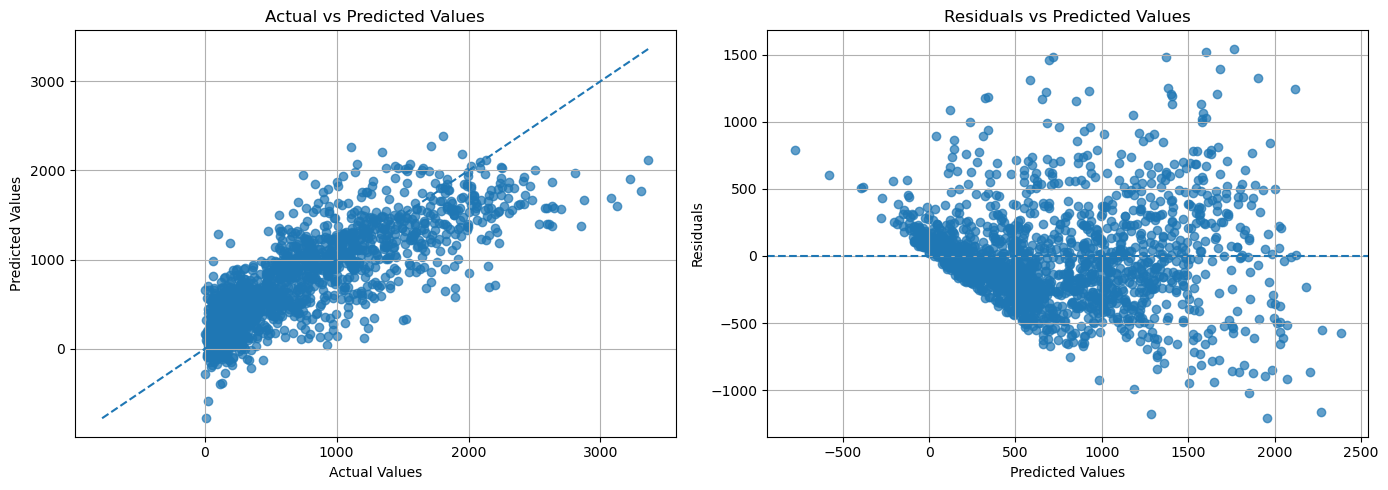

In [ ]:
pipe = make_pipeline(
    preprocessing,
    LinearRegression()
)

param_grid = {
    "columntransformer__num__polynomialfeatures__degree": [2, 3, 4] 
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="r2",
    cv=5
)


grid.fit(X_train, y_train)

model = grid.best_estimator_
y_pred = model.predict(X_test)

print("Test R2:", r2_score(y_test, y_pred))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("Test MAE:", mean_absolute_error(y_test, y_pred))

residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

axes[0].plot([min_val, max_val], [min_val, max_val], linestyle="--")
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Actual vs Predicted Values")
axes[0].grid(True)

# 2. Residuals vs Predicted
axes[1].scatter(y_pred, residuals, alpha=0.7)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Predicted Values")
axes[1].grid(True)

plt.tight_layout()
plt.show()


## Evaluation
The best polynomial regression pipeline can be evaluated on the test set with standard regression metrics.
